In [1]:
import os
import glob
import re
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif"
})

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded and seed set.")

Libraries loaded and seed set.


In [2]:
# Map raw method names from PKL files to internal keys
LABEL_MAP = {
    # DiRoCA variants
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)':     'DiRoCA_0p5',
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DiRoCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DiRoCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DiRoCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DiRoCA_8',
    
    # Baselines
    'Gradca':                'GradCA',
    'Baryca':                'BARYCA',
    'Abs-LiNGAM (Perfect)':  'Abslin_p',
    'Abs-LiNGAM (Noisy)':    'Abslin_n',
}

# Map internal keys to LaTeX display labels
PRINT_LABEL_MAP = {
    'DiRoCA_star': r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DiRoCA_0p5':  r'DiRoCA$_{0.5,0.5}$',
    'DiRoCA_1':    r'DiRoCA$_{1,1}$',
    'DiRoCA_2':    r'DiRoCA$_{2,2}$',
    'DiRoCA_4':    r'DiRoCA$_{4,4}$',
    'DiRoCA_8':    r'DiRoCA$_{8,8}$',
    'GradCA':      r'GRAD$_{(\tau,\omega)}$',
    'BARYCA':      r'BARY$_{(\tau,\omega)}$',
    'Abslin_p':    r'AbsLin$_{\text{p}}$',
    'Abslin_n':    r'AbsLin$_{\text{n}}$',
}

# Define color palette
ALL_METHODS = list(PRINT_LABEL_MAP.keys())
palette = sns.color_palette("colorblind", n_colors=len(ALL_METHODS))
COLOR_MAP = dict(zip([PRINT_LABEL_MAP[m] for m in ALL_METHODS], palette))

# Specific overrides for consistency if desired
COLOR_MAP.update({
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4',
    r'DiRoCA$_{0.5,0.5}$': '#17becf',
    r'GRAD$_{(\tau,\omega)}$': '#2ca02c',
    r'BARY$_{(\tau,\omega)}$': '#d62728',
})

In [3]:
def load_battery_results(distribution='gaussian', 
                         shift_type='additive', 
                         base_dir="data/battery/evaluation_results"):
    """
    Loads the most recent battery evaluation result file.
    """
    # Matches pattern: battery_eval_additive_gaussian_*.pkl
    pattern = os.path.join(base_dir, f"battery_eval_{shift_type}_{distribution}_*.pkl")
    files = sorted(glob.glob(pattern))
    
    if not files:
        print(f"No files found for pattern: {pattern}")
        return None
        
    latest_file = files[-1]
    print(f"Loading: {os.path.basename(latest_file)}")
    
    df = pd.read_pickle(latest_file)
    
    # Pre-processing
    if 'method' in df.columns:
        df['method'] = df['method'].replace(LABEL_MAP)
        df['display_name'] = df['method'].map(PRINT_LABEL_MAP)
        
    return df

def get_closest_sigma(df, target_sigma):
    """Finds available sigma closest to target."""
    sigmas = np.sort(df['noise_scale'].unique())
    idx = np.argmin(np.abs(sigmas - target_sigma))
    closest = sigmas[idx]
    return closest

In [4]:
def plot_robustness_curves(df, 
                           methods_to_plot, 
                           x_col, 
                           fixed_col, 
                           fixed_val, 
                           title_suffix="",
                           figsize=(8, 5)):
    """
    Generic plotting function for Alpha vs Error or Sigma vs Error.
    """
    # Filter data
    mask = (np.isclose(df[fixed_col], fixed_val)) & (df['method'].isin(methods_to_plot))
    plot_df = df[mask].copy()
    
    if plot_df.empty:
        print(f"No data found for {fixed_col}={fixed_val} with specified methods.")
        return

    # Order hues based on input list
    hue_order = [PRINT_LABEL_MAP[m] for m in methods_to_plot if m in PRINT_LABEL_MAP]
    
    plt.figure(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x=x_col,
        y='error',
        hue='display_name',
        hue_order=hue_order,
        palette=COLOR_MAP,
        marker='o',
        linewidth=2.5,
        markersize=7,
        errorbar='sd'
    )
    
    # Formatting
    xlabel = r'$\alpha$' if x_col == 'alpha' else r'$\tilde{\sigma}$'
    fixed_label = r'$\tilde{\sigma}$' if fixed_col == 'noise_scale' else r'$\alpha$'
    
    plt.title(f"Robustness: Error vs {xlabel} ({fixed_label} $\\approx$ {fixed_val:.2f}) {title_suffix}", fontsize=14)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Abstraction Error", fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=11)
    plt.tight_layout()
    plt.show()

def run_plots(df, methods_to_plot, target_sigma=5.0, target_alpha=1.0):
    # 1. Fix Sigma, Vary Alpha
    real_sigma = get_closest_sigma(df, target_sigma)
    plot_robustness_curves(df, methods_to_plot, x_col='alpha', 
                           fixed_col='noise_scale', fixed_val=real_sigma)
    
    # 2. Fix Alpha, Vary Sigma
    # (Cap sigma for plotting clarity if needed, e.g., <= 5.0)
    sigmas = np.sort(df['noise_scale'].unique())
    # max_sig = sigmas[sigmas <= 5.5].max() 
    # df_subset = df[df['noise_scale'] <= max_sig] # Optional clipping
    
    plot_robustness_curves(df, methods_to_plot, x_col='noise_scale', 
                           fixed_col='alpha', fixed_val=target_alpha)

In [ ]:
def generate_stats_table(df, methods_of_interest, alpha_vals=[0.0, 1.0], target_sigma=5.0):
    """
    Generates a summary table. 
    For each Alpha, it automatically picks the method with the LOWEST error as the Reference.
    """
    real_sigma = get_closest_sigma(df, target_sigma)
    print(f"Generating stats for Sigma ≈ {real_sigma:.3f}")
    
    results = []
    
    # Filter for sigma
    df_sig = df[np.isclose(df['noise_scale'], real_sigma)].copy()
    
    for alpha in alpha_vals:
        df_alpha = df_sig[np.isclose(df_sig['alpha'], alpha)].copy()
        
        # 1. Pivot to get paired samples for T-Test
        pivot_cols = [c for c in ['fold', 'trial', 'seed'] if c in df_alpha.columns]
        if not pivot_cols:
            print(f"Warning: No fold/trial columns found. Skipping t-test for alpha={alpha}")
            paired_df = None
        else:
            paired_df = df_alpha.pivot_table(index=pivot_cols, columns='method', values='error')
        
        if paired_df is None or paired_df.empty:
            continue

        # 2. Identify the WINNER (Lowest Mean Error) for this specific alpha
        # Only consider methods in our interest list
        valid_methods = [m for m in methods_of_interest if m in paired_df.columns]
        if not valid_methods:
            continue
            
        mean_scores = paired_df[valid_methods].mean()
        best_method = mean_scores.idxmin() # Name of the method with lowest error
        best_method_display = PRINT_LABEL_MAP.get(best_method, best_method)
        
        print(f"  > Alpha={alpha}: Best method is {best_method_display} (Error={mean_scores[best_method]:.2f})")

        # 3. Compare everyone else against the Winner
        ref_scores = paired_df[best_method]

        for method in methods_of_interest:
            if method not in paired_df.columns: 
                continue

            method_scores = paired_df[method]
            mean_err = method_scores.mean()
            std_err = method_scores.std()
            
            sig_str = ""
            
            if method == best_method:
                sig_str = "--- (Ref)"
            else:
                # Align indices for paired t-test
                common_idx = ref_scores.dropna().index.intersection(method_scores.dropna().index)
                if len(common_idx) > 1:
                    stat, p_val = ttest_rel(ref_scores.loc[common_idx], method_scores.loc[common_idx])
                    
                    # Since Ref is the "Best" (lowest error), a significant diff means 
                    # the other method is significantly WORSE.
                    if p_val < 0.001:
                        sig_str = "***"
                    elif p_val < 0.01:
                        sig_str = "**"
                    elif p_val < 0.05:
                        sig_str = "*"
            
            results.append({
                "Condition": f"α={alpha}",
                "Method": PRINT_LABEL_MAP.get(method, method),
                "Mean Error": mean_err,
                "Std": std_err,
                "Sig. vs Best": sig_str
            })
            
    # Format DataFrame
    res_df = pd.DataFrame(results)
    
    # Display
    print(f"\nStatistical Summary (Dynamic Reference: Best Method per Condition)")
    print(f"Significance (* p<0.05) indicates the method is significantly worse than the Best Method.")
    
    for alpha in alpha_vals:
        print(f"\n--- Alpha = {alpha} ---")
        sub = res_df[res_df['Condition'] == f"α={alpha}"].sort_values("Mean Error")
        print(sub.drop(columns=['Condition']).to_string(index=False, float_format="%.4f"))

    return res_df

Loading: battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_150415.pkl

Generating Plots...


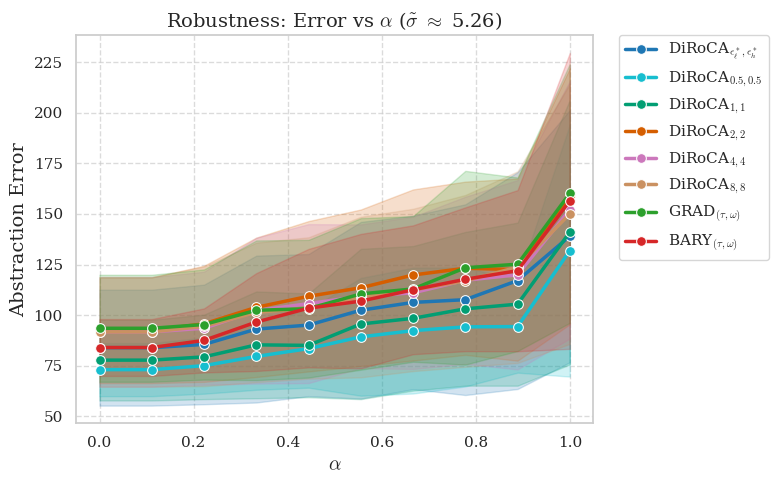

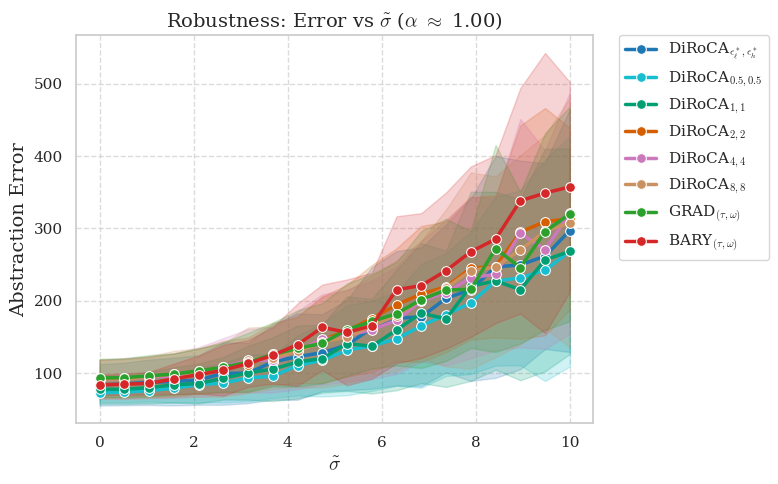


Generating Statistics...
Generating stats for Sigma ≈ 5.263

Statistical Summary (Reference: DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$)
Significance levels: * p<0.05, ** p<0.01, *** p<0.001 (paired t-test)

--- Alpha = 0.0 ---
                                  Method  Mean Error     Std            Sig.
                      DiRoCA$_{0.5,0.5}$     73.1040 13.1157 *** (Ref Worse)
                          DiRoCA$_{1,1}$     77.7995 19.9292     (Ref Worse)
DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$     83.9622 28.6361                
                  BARY$_{(\tau,\omega)}$     84.0323 14.0605                
                          DiRoCA$_{4,4}$     91.7588 27.0872              **
                          DiRoCA$_{8,8}$     91.7588 27.0872              **
                          DiRoCA$_{2,2}$     92.5506 26.1101             ***
                  GRAD$_{(\tau,\omega)}$     93.5285 26.4270             ***

--- Alpha = 1.0 ---
                                  Method  Mean Error     St

In [16]:
# 1. Load Data
distribution = 'gaussian' # 'student-t', 'exponential'
df_results = load_battery_results(distribution=distribution)

# 2. Select Methods to Analyze
selected_methods = [
    'DiRoCA_star', 
    'DiRoCA_0p5',
    'DiRoCA_1', 
    'DiRoCA_2',
    'DiRoCA_4', 
    'DiRoCA_8',
    'GradCA', 
    'BARYCA', 
    # 'Abslin_p',
    # 'Abslin_n'
]

if df_results is not None:
    # 3. Generate Visualizations
    print("\nGenerating Plots...")
    run_plots(
        df_results, 
        selected_methods, 
        target_sigma=5.0,
        target_alpha=1.0 
    )
    
    # 4. Generate Stats Table (Dynamic Best Reference)
    print("\nGenerating Statistics...")
    stats_df = generate_stats_table(
        df_results, 
        selected_methods, 
        alpha_vals=[0.0, 1.0], 
        target_sigma=5.0
        # No reference_method arg needed anymore
    )

In [17]:
import os
import glob
import re
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Visual styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titleweight": "bold"
})

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Mappings
LABEL_MAP = {
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)':     'DiRoCA_0p5',
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DiRoCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DiRoCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DiRoCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DiRoCA_8',
    'Gradca': 'GradCA', 'GradCA': 'GradCA',
    'Baryca': 'BARYCA', 'BaryCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)':   'Abslin_n',
}

PRINT_LABEL_MAP = {
    'DiRoCA_star': r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DiRoCA_0p5':  r'DiRoCA$_{0.5}$',
    'DiRoCA_1':    r'DiRoCA$_{1.0}$',
    'DiRoCA_2':    r'DiRoCA$_{2.0}$',
    'DiRoCA_4':    r'DiRoCA$_{4.0}$',
    'DiRoCA_8':    r'DiRoCA$_{8.0}$',
    'GradCA':      r'GradCA (ERM)',
    'BARYCA':      r'BaryCA',
    'Abslin_p':    r'AbsLin$_{\text{p}}$',
    'Abslin_n':    r'AbsLin$_{\text{n}}$',
}

# Define color palette
palette = sns.color_palette("colorblind", n_colors=10)
COLOR_MAP = dict(zip(PRINT_LABEL_MAP.values(), palette))
# Overrides for consistency
COLOR_MAP[r'DiRoCA$_{0.5}$'] = '#17becf' # Cyan for best DiRoCA
COLOR_MAP[r'GradCA (ERM)'] = '#2ca02c'   # Green for GradCA

In [18]:
def load_battery_results(distribution='gaussian', shift_type='additive', base_dir="data/battery/evaluation_results"):
    pattern = os.path.join(base_dir, f"battery_eval_{shift_type}_{distribution}_*.pkl")
    files = sorted(glob.glob(pattern), key=os.path.getmtime)
    
    if not files:
        print(f"⚠️ No files found for {distribution}")
        return None
        
    latest_file = files[-1]
    print(f"📂 Loading {distribution.upper()}: {os.path.basename(latest_file)}")
    
    df = pd.read_pickle(latest_file)
    if 'method' in df.columns:
        df['method'] = df['method'].replace(LABEL_MAP)
        df['display_name'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
        
    return df

def get_closest_sigma(df, target_sigma):
    sigmas = np.sort(df['noise_scale'].unique())
    idx = np.argmin(np.abs(sigmas - target_sigma))
    return sigmas[idx]

In [19]:
def plot_robustness_curves(df, methods_to_plot, x_col, fixed_col, fixed_val, title_prefix, ax):
    """Generic plotting on a specific ax."""
    mask = (np.isclose(df[fixed_col], fixed_val)) & (df['method'].isin(methods_to_plot))
    plot_df = df[mask].copy()
    
    if plot_df.empty: return

    hue_order = [PRINT_LABEL_MAP[m] for m in methods_to_plot if m in PRINT_LABEL_MAP]
    
    sns.lineplot(
        data=plot_df, x=x_col, y='error', hue='display_name',
        hue_order=hue_order, palette=COLOR_MAP,
        marker='o', linewidth=2.5, markersize=8, errorbar='sd', ax=ax
    )
    
    xlabel = r'Shift Intensity ($\alpha$)' if x_col == 'alpha' else r'Noise Scale ($\tilde{\sigma}$)'
    fixed_label = r'$\tilde{\sigma}$' if fixed_col == 'noise_scale' else r'$\alpha$'
    
    ax.set_title(f"{title_prefix}\n({fixed_label} $\\approx$ {fixed_val:.1f})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Abstraction Error")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.get_legend().remove()

def generate_plots_for_dist(df, methods, dist_name):
    """Generates side-by-side plots for one distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Alpha Sweep (at max sigma)
    max_sigma = df['noise_scale'].max()
    plot_robustness_curves(df, methods, 'alpha', 'noise_scale', max_sigma, 
                           f"{dist_name.capitalize()}: Robustness to Shift", axes[0])
    
    # 2. Noise Sweep (at max alpha)
    plot_robustness_curves(df, methods, 'noise_scale', 'alpha', 1.0, 
                           f"{dist_name.capitalize()}: Robustness to Noise", axes[1])
    
    # Unified Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=5, frameon=False)
    plt.tight_layout()
    plt.show()

In [20]:
def generate_dynamic_stats(df, methods, alpha_vals=[0.0, 1.0], target_sigma=5.0):
    real_sigma = get_closest_sigma(df, target_sigma)
    print(f"\n📊 Stats for Sigma ≈ {real_sigma:.2f}")
    
    # Filter for sigma
    df_sig = df[np.isclose(df['noise_scale'], real_sigma)].copy()
    
    results = []
    
    for alpha in alpha_vals:
        df_alpha = df_sig[np.isclose(df_sig['alpha'], alpha)].copy()
        
        # Pivot for paired tests
        pivot_cols = [c for c in ['fold', 'trial', 'seed'] if c in df_alpha.columns]
        paired_df = df_alpha.pivot_table(index=pivot_cols, columns='method', values='error')
        
        # Filter valid methods present in this DF
        valid_methods = [m for m in methods if m in paired_df.columns]
        if not valid_methods: continue
            
        # 1. Find the Winner (Lowest Mean Error)
        means = paired_df[valid_methods].mean()
        winner = means.idxmin()
        winner_score = means[winner]
        
        print(f"  > Alpha={alpha}: Winner is {PRINT_LABEL_MAP.get(winner, winner)} (Err={winner_score:.2f})")
        
        # 2. Compare everyone to Winner
        ref_scores = paired_df[winner]
        
        for m in valid_methods:
            scores = paired_df[m]
            mean_err = scores.mean()
            std_err = scores.std()
            
            sig = ""
            if m == winner:
                sig = "--- (Ref)"
            else:
                # Paired t-test
                common = ref_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(ref_scores.loc[common], scores.loc[common])
                    if p < 0.001: sig = "***"
                    elif p < 0.01: sig = "**"
                    elif p < 0.05: sig = "*"
            
            results.append({
                "Alpha": alpha,
                "Method": PRINT_LABEL_MAP.get(m, m),
                "Error": f"{mean_err:.2f} ± {std_err:.2f}",
                "Raw_Mean": mean_err, # For sorting
                "Sig.": sig
            })
            
    # Display Tables
    res_df = pd.DataFrame(results)
    for alpha in alpha_vals:
        print(f"\n--- Table: Alpha = {alpha} ---")
        sub = res_df[res_df['Alpha'] == alpha].sort_values("Raw_Mean")
        print(sub[['Method', 'Error', 'Sig.']].to_string(index=False))


ANALYSIS: GAUSSIAN NOISE
📂 Loading GAUSSIAN: battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_150415.pkl


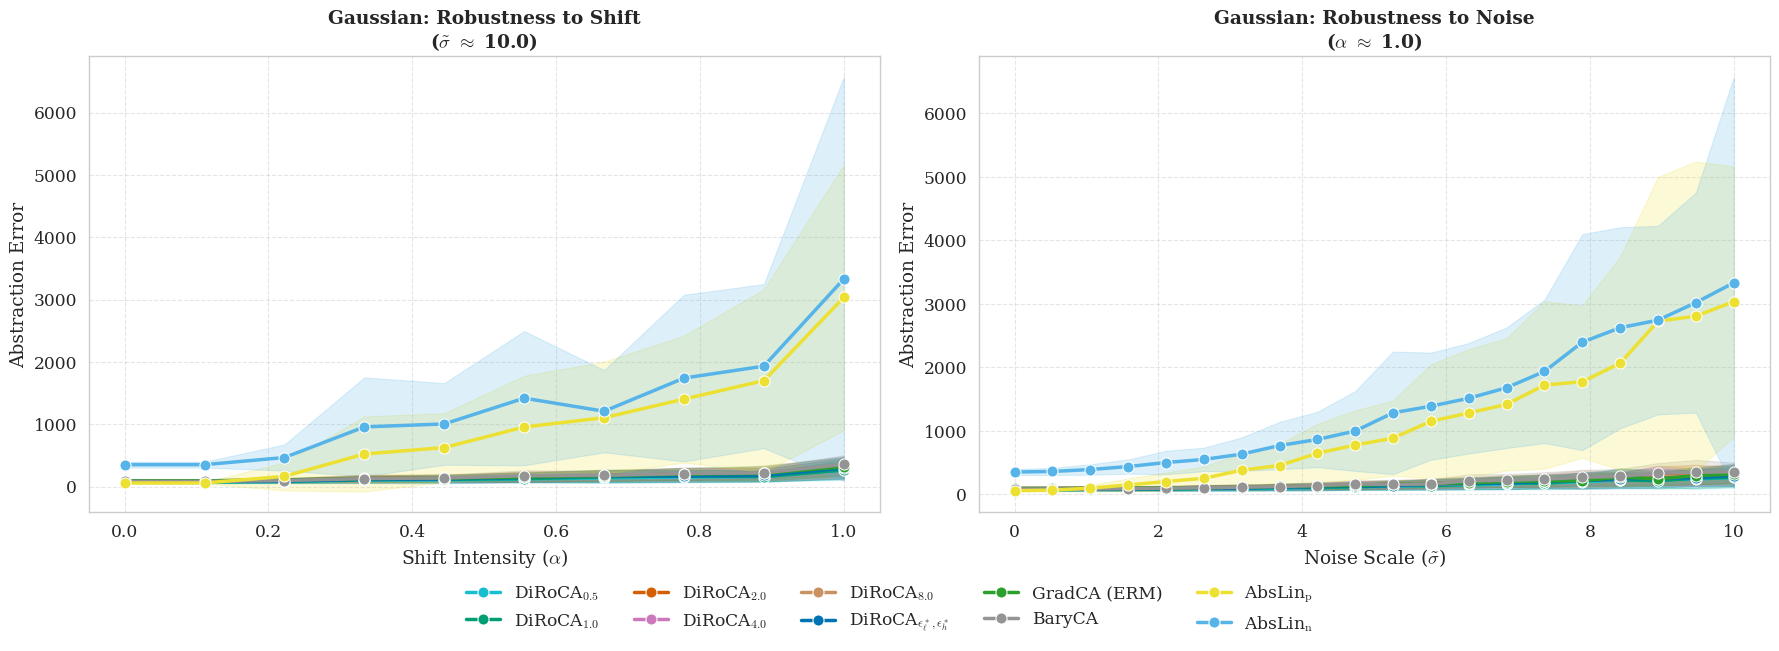


📊 Stats for Sigma ≈ 10.00
  > Alpha=0.0: Winner is AbsLin$_{\text{p}}$ (Err=58.85)
  > Alpha=1.0: Winner is DiRoCA$_{0.5}$ (Err=268.35)

--- Table: Alpha = 0.0 ---
                                  Method          Error      Sig.
                     AbsLin$_{\text{p}}$  58.85 ± 11.27 --- (Ref)
                          DiRoCA$_{0.5}$  73.10 ± 13.12       ***
                          DiRoCA$_{1.0}$  77.80 ± 19.93       ***
DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$  83.96 ± 28.64       ***
                                  BaryCA  84.03 ± 14.06       ***
                          DiRoCA$_{4.0}$  91.76 ± 27.09       ***
                          DiRoCA$_{8.0}$  91.76 ± 27.09       ***
                          DiRoCA$_{2.0}$  92.55 ± 26.11       ***
                            GradCA (ERM)  93.53 ± 26.43       ***
                     AbsLin$_{\text{n}}$ 352.82 ± 47.07       ***

--- Table: Alpha = 1.0 ---
                                  Method             Error      Sig.
            

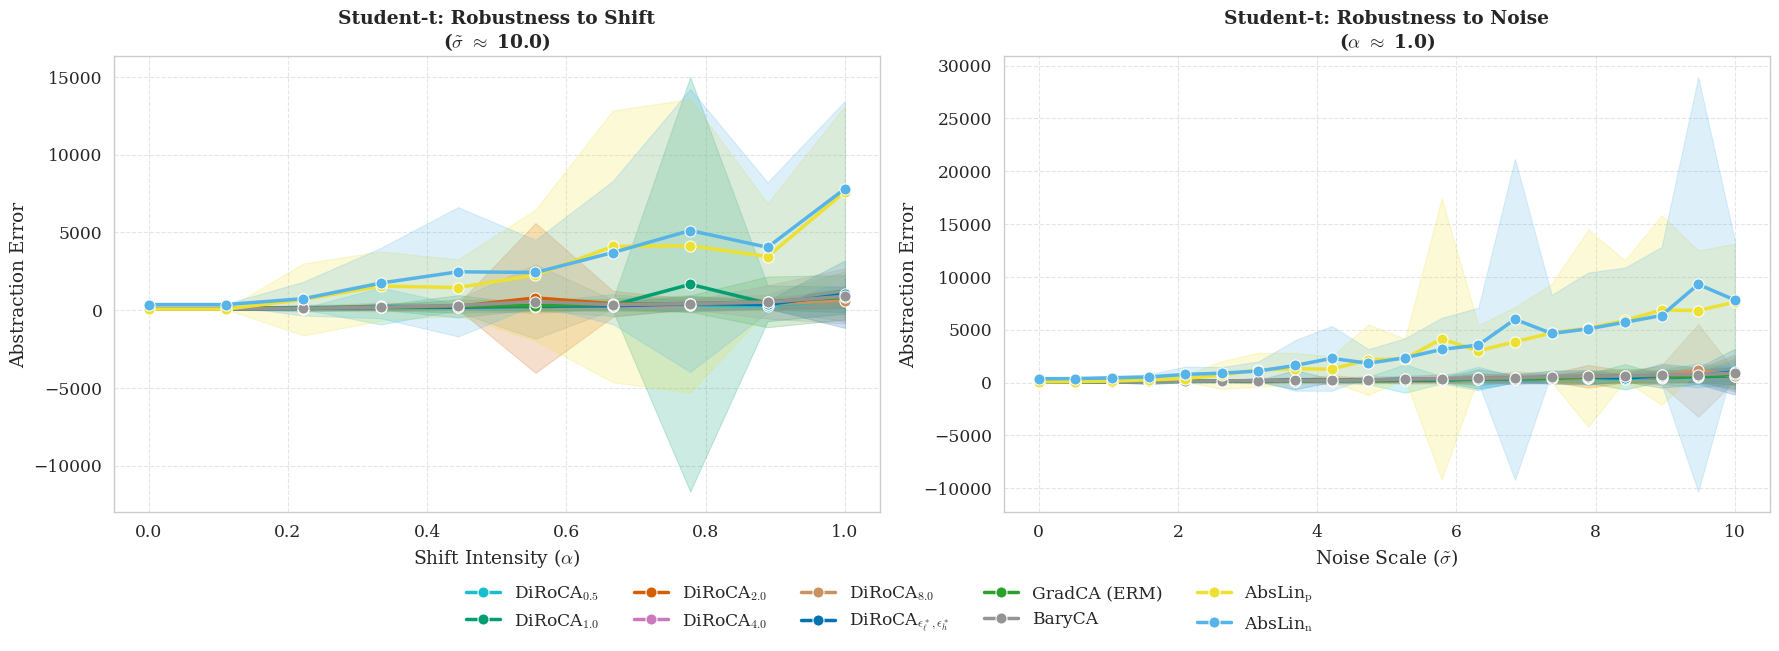


📊 Stats for Sigma ≈ 10.00
  > Alpha=0.0: Winner is AbsLin$_{\text{p}}$ (Err=58.85)
  > Alpha=1.0: Winner is DiRoCA$_{8.0}$ (Err=612.49)

--- Table: Alpha = 0.0 ---
                                  Method          Error      Sig.
                     AbsLin$_{\text{p}}$  58.85 ± 11.27 --- (Ref)
                          DiRoCA$_{0.5}$  73.10 ± 13.12       ***
                          DiRoCA$_{1.0}$  77.80 ± 19.93       ***
DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$  83.96 ± 28.64       ***
                                  BaryCA  84.03 ± 14.06       ***
                          DiRoCA$_{4.0}$  91.76 ± 27.09       ***
                          DiRoCA$_{8.0}$  91.76 ± 27.09       ***
                          DiRoCA$_{2.0}$  92.55 ± 26.11       ***
                            GradCA (ERM)  93.53 ± 26.43       ***
                     AbsLin$_{\text{n}}$ 352.82 ± 47.07       ***

--- Table: Alpha = 1.0 ---
                                  Method             Error      Sig.
            

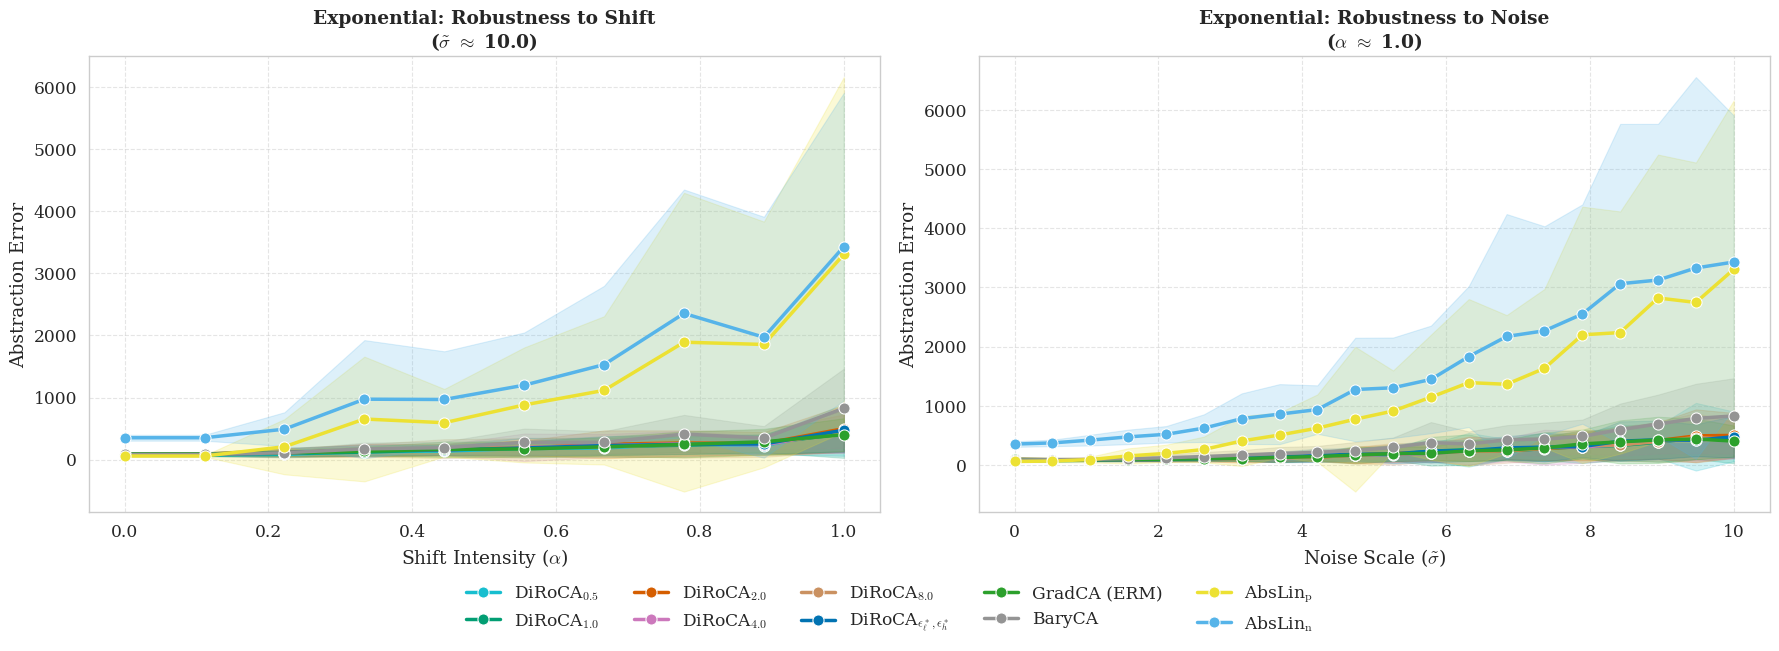


📊 Stats for Sigma ≈ 10.00
  > Alpha=0.0: Winner is AbsLin$_{\text{p}}$ (Err=58.85)
  > Alpha=1.0: Winner is GradCA (ERM) (Err=403.22)

--- Table: Alpha = 0.0 ---
                                  Method          Error      Sig.
                     AbsLin$_{\text{p}}$  58.85 ± 11.27 --- (Ref)
                          DiRoCA$_{0.5}$  73.10 ± 13.12       ***
                          DiRoCA$_{1.0}$  77.80 ± 19.93       ***
DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$  83.96 ± 28.64       ***
                                  BaryCA  84.03 ± 14.06       ***
                          DiRoCA$_{4.0}$  91.76 ± 27.09       ***
                          DiRoCA$_{8.0}$  91.76 ± 27.09       ***
                          DiRoCA$_{2.0}$  92.55 ± 26.11       ***
                            GradCA (ERM)  93.53 ± 26.43       ***
                     AbsLin$_{\text{n}}$ 352.82 ± 47.07       ***

--- Table: Alpha = 1.0 ---
                                  Method             Error      Sig.
              

In [22]:
# Select Methods
METHODS = [
    'DiRoCA_0p5', 'DiRoCA_1', 'DiRoCA_2', 'DiRoCA_4', 'DiRoCA_8', 'DiRoCA_star',
    'GradCA', 'BARYCA', 'Abslin_p', 'Abslin_n'
]

DISTRIBUTIONS = ['gaussian', 'student-t', 'exponential']

for dist in DISTRIBUTIONS:
    print("\n" + "="*80)
    print(f"ANALYSIS: {dist.upper()} NOISE")
    print("="*80)
    
    df = load_battery_results(dist)
    
    if df is not None:
        # 1. Plots
        generate_plots_for_dist(df, METHODS, dist)
        
        # 2. Tables (Alpha 0 & 1)
        # Using max noise scale found in file for worst-case analysis
        max_sig = df['noise_scale'].max() 
        generate_dynamic_stats(df, METHODS, alpha_vals=[0.0, 1.0], target_sigma=max_sig)